# Baseline v1 — data preparation

**Scope:** `stance` as target, single feature = `headline` + `body` (raw) as one string<br>
**stratified** train/val/test split (70/15/15)<br>
**TF–IDF fit on training text only**, then transform val/test (no leakage).

In [1]:
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
PROCESSED = Path("../data/processed")
PROCESSED.mkdir(parents=True, exist_ok=True)

DATA_PATH = Path("../data/balanced_undersampled_data.csv")

In [2]:
df = pd.read_csv(DATA_PATH)
assert {"headline", "stance", "body"}.issubset(df.columns), "expected headline, body, stance columns"

df["text"] = (
    df["headline"].fillna("").astype(str).str.strip()
    + " \n "
    + df["body"].fillna("").astype(str).str.strip()
)
X = df["text"]
y = df["stance"]

print("rows:", len(df))
print("stance counts:\n", y.value_counts().sort_index())

rows: 6148
stance counts:
 stance
agree        1537
disagree     1537
discuss      1537
unrelated    1537
Name: count, dtype: int64


In [3]:
# Stratified 70 / 15 / 15: first hold out test, then split remainder into train and val
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

val_fraction_of_trainval = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval,
    y_trainval,
    test_size=val_fraction_of_trainval,
    stratify=y_trainval,
    random_state=RANDOM_STATE,
)

for name, yt in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(name, len(yt), "|", yt.value_counts().sort_index().to_dict())

train 4302 | {'agree': 1076, 'disagree': 1076, 'discuss': 1075, 'unrelated': 1075}
val 923 | {'agree': 230, 'disagree': 231, 'discuss': 231, 'unrelated': 231}
test 923 | {'agree': 231, 'disagree': 230, 'discuss': 231, 'unrelated': 231}


In [4]:
# Save readable splits (text + stance only)
train_out = pd.DataFrame({"text": X_train, "stance": y_train})
val_out = pd.DataFrame({"text": X_val, "stance": y_val})
test_out = pd.DataFrame({"text": X_test, "stance": y_test})

train_out.to_csv(PROCESSED / "v1_train.csv", index=False)
val_out.to_csv(PROCESSED / "v1_val.csv", index=False)
test_out.to_csv(PROCESSED / "v1_test.csv", index=False)
print("Wrote CSVs to", PROCESSED.resolve())

Wrote CSVs to D:\DePaul\Q6 final\DSC 672 Data Science Capstone\Fake News Detection\data\processed


In [5]:
# TF–IDF: fit on TRAIN only, then transform val/test
vectorizer = TfidfVectorizer(
    max_features=20_000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("TF–IDF shape train:", X_train_tfidf.shape)
print("TF–IDF shape val:  ", X_val_tfidf.shape)
print("TF–IDF shape test: ", X_test_tfidf.shape)

sparse.save_npz(PROCESSED / "v1_X_train_tfidf.npz", X_train_tfidf)
sparse.save_npz(PROCESSED / "v1_X_val_tfidf.npz", X_val_tfidf)
sparse.save_npz(PROCESSED / "v1_X_test_tfidf.npz", X_test_tfidf)

np.save(PROCESSED / "v1_y_train.npy", y_train.to_numpy())
np.save(PROCESSED / "v1_y_val.npy", y_val.to_numpy())
np.save(PROCESSED / "v1_y_test.npy", y_test.to_numpy())

joblib.dump(vectorizer, PROCESSED / "v1_tfidf_vectorizer.joblib")
print("Wrote .npz, .npy, and vectorizer to", PROCESSED.resolve())

TF–IDF shape train: (4302, 20000)
TF–IDF shape val:   (923, 20000)
TF–IDF shape test:  (923, 20000)
Wrote .npz, .npy, and vectorizer to D:\DePaul\Q6 final\DSC 672 Data Science Capstone\Fake News Detection\data\processed


## Model Training

In [9]:
from scipy import sparse
import numpy as np
import joblib
from pathlib import Path

p = Path("../data/processed")
X_train = sparse.load_npz(p / "v1_X_train_tfidf.npz")
y_train = np.load(p / "v1_y_train.npy", allow_pickle=True)

X_val = sparse.load_npz(p / "v1_X_val_tfidf.npz")
y_val = np.load(p / "v1_y_val.npy", allow_pickle=True)

X_test = sparse.load_npz(p / "v1_X_test_tfidf.npz")
y_test = np.load(p / "v1_y_test.npy", allow_pickle=True)

In [10]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

RANDOM_STATE = 42

clf = LogisticRegression(
    max_iter=2000,
    random_state=RANDOM_STATE,
    solver="saga",
    multi_class="multinomial",
)

clf.fit(X_train, y_train)

d:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=2000, multi_class='multinomial', random_state=42,
                   solver='saga')

In [12]:
# saving model
joblib.dump(clf, "../models/v1_logistic_regression.joblib")
print("Saved classifier")

Saved classifier


## Model Eval

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)

LABELS = ['agree', 'disagree', 'discuss', 'unrelated']

# get predictions
y_pred_train = clf.predict(X_train)
y_pred_val = clf.predict(X_val)
y_pred_test = clf.predict(X_test)


In [17]:
def print_split_metrics(name, y_true, y_pred, labels):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro", labels=labels, zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average="weighted", labels=labels, zero_division=0)
    micro_f1 = f1_score(y_true, y_pred, average="micro", labels=labels, zero_division=0)
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(f"accuracy:       {acc:.4f}")
    print(f"micro F1:       {micro_f1:.4f}")
    print(f"macro F1:       {macro_f1:.4f}")
    print(f"weighted F1:    {weighted_f1:.4f}")
    print("\nClassification report (precision / recall / F1 / support):")
    print(classification_report(y_true, y_pred, labels=labels, digits=4, zero_division=0))


In [18]:
# get metrics
print_split_metrics("TRAIN", y_train, y_pred_train, LABELS)
print_split_metrics("VAL", y_val, y_pred_val, LABELS)
print_split_metrics("TEST", y_test, y_pred_test, LABELS)


TRAIN
accuracy:       0.7671
micro F1:       0.7671
macro F1:       0.7659
weighted F1:    0.7659

Classification report (precision / recall / F1 / support):
              precision    recall  f1-score   support

       agree     0.7500    0.7082    0.7285      1076
    disagree     0.7333    0.8690    0.7954      1076
     discuss     0.7983    0.7879    0.7931      1075
   unrelated     0.7958    0.7033    0.7467      1075

    accuracy                         0.7671      4302
   macro avg     0.7694    0.7671    0.7659      4302
weighted avg     0.7693    0.7671    0.7659      4302


VAL
accuracy:       0.5840
micro F1:       0.5840
macro F1:       0.5797
weighted F1:    0.5797

Classification report (precision / recall / F1 / support):
              precision    recall  f1-score   support

       agree     0.5550    0.5261    0.5402       230
    disagree     0.6581    0.7749    0.7117       231
     discuss     0.6109    0.5844    0.5973       231
   unrelated     0.4906    0.450

In [19]:
# store metrics for v1
rows = []
for split_name, y_true, y_pred in [
    ("train", y_train, y_pred_train),
    ("val", y_val, y_pred_val),
    ("test", y_test, y_pred_test),
]:
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=LABELS, zero_division=0)
    for i, lab in enumerate(LABELS):
        rows.append(
            {
                "split": split_name,
                "stance": lab,
                "precision": p[i],
                "recall": r[i],
                "f1": f[i],
                "support": int(s[i]),
            }
        )
detailed_df = pd.DataFrame(rows)
print("\nPer-class F1 by split:")
display(detailed_df.pivot(index="stance", columns="split", values="f1").round(4))



Per-class F1 by split:


split,test,train,val
stance,,,
agree,0.5503,0.7285,0.5402
disagree,0.6640,0.7954,0.7117
discuss,0.5817,0.7931,0.5973
unrelated,0.4753,0.7467,0.4695


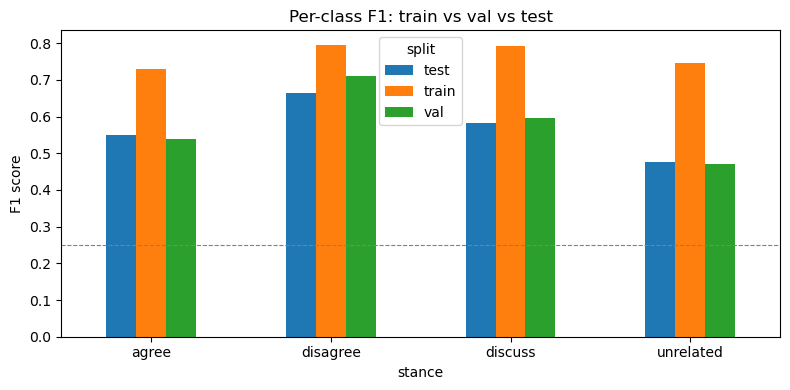

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
pivot_f1 = detailed_df.pivot(index="stance", columns="split", values="f1")
pivot_f1.plot(kind="bar", ax=ax, rot=0)
ax.set_ylabel("F1 score")
ax.set_title("Per-class F1: train vs val vs test")
ax.legend(title="split")
ax.axhline(0.25, color="gray", linestyle="--", linewidth=0.8, label="random 4-class")
plt.tight_layout()
plt.show()


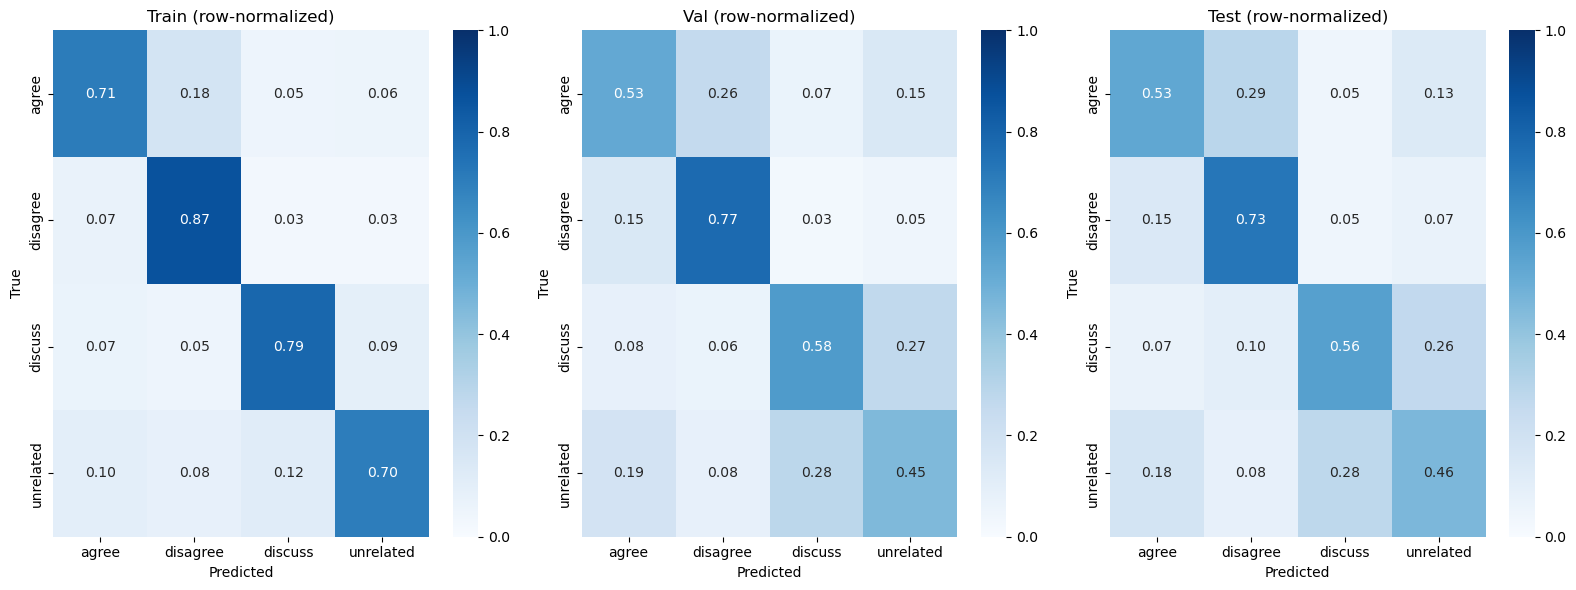

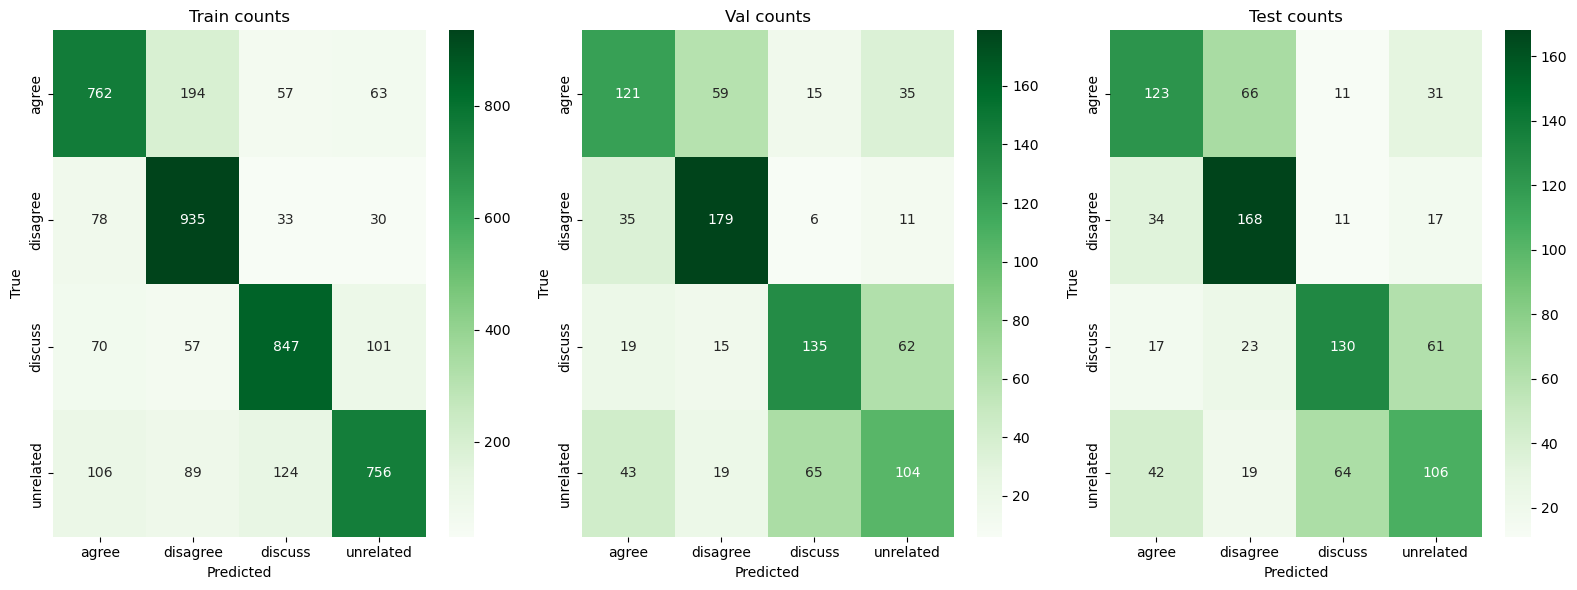

In [26]:
def plot_cm_norm(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS, normalize="true")
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=LABELS,
        yticklabels=LABELS,
        ax=ax,
        vmin=0,
        vmax=1,
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

plot_cm_norm(y_train, y_pred_train, "Train (row-normalized)", axes[0])
plot_cm_norm(y_val, y_pred_val, "Val (row-normalized)", axes[1])
plot_cm_norm(y_test, y_pred_test, "Test (row-normalized)", axes[2])
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
for ax, (y_true, y_pred, title) in zip(
    axes,
    [
        (y_train, y_pred_train, "Train counts"),
        (y_val, y_pred_val, "Val counts"),
        (y_test, y_pred_test, "Test counts"),
    ],
):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=LABELS, yticklabels=LABELS, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
plt.tight_layout()
plt.show()

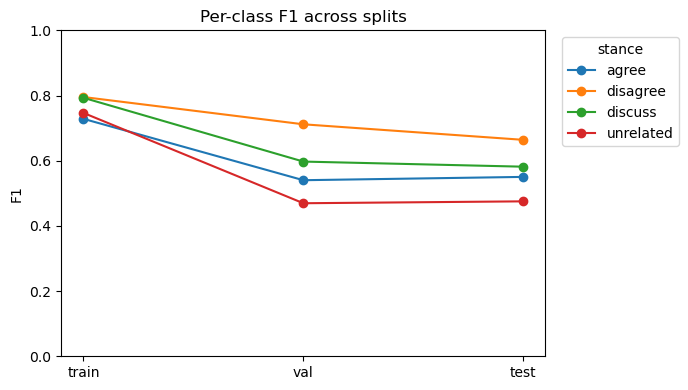

In [28]:
pivot = detailed_df.pivot(index="split", columns="stance", values="f1")
pivot = pivot.reindex(["train", "val", "test"])

fig, ax = plt.subplots(figsize=(7, 4))
for stance in pivot.columns:
    ax.plot(pivot.index, pivot[stance], marker="o", label=stance)
ax.set_ylim(0, 1)
ax.set_ylabel("F1")
ax.set_title("Per-class F1 across splits")
ax.legend(title="stance", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()